In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [45]:
from google.colab import drive
drive.mount('/content/drive')

PATH = '/content/drive/MyDrive'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data

We will load only the PCA data as we have already decided that the models based on it are the chosen candidates.

In [46]:
# Path for PCA dataset
data_pca_path = f'{PATH}/Datasets/pca_results.csv'

# Read the datasets
df = pd.read_csv(data_pca_path)

In [47]:
y = df['Kingdom']
X = df.drop('Kingdom', axis=1)

### Train test split

We will split the data using random_state = 42 as we have done when training all the previous models. The training was done on the same PCA, hence why we unified the random state to avoid data leakage when testing the Ensemble.

We will not be defining a train data, because the models are pretrained, we only require the test to asses the Ensemble.

In [48]:
_ , X_test, _ , y_test = train_test_split(X, y, random_state= 42, test_size= 0.2, stratify=y)

## Pretrained Models

Importing the pretrained models: KNN, RF and SVM, all of which have been trained on the PCA data.

In [51]:
import joblib # To handle loading model .pkl files
rf_model = joblib.load(f'{PATH}/Models/RF_model.pkl')
svm_model = joblib.load(f'{PATH}/Models/SVM.pkl')
knn_model = joblib.load(f'{PATH}/Models/KNN.pkl')

We have to make sure the classes are in order to ensure the pred probabilities given by each model are in order.




In [52]:
print(f"RF Classes:  {rf_model.classes_}")
print(f"SVM Classes: {svm_model.classes_}")
print(f"KNN Classes: {knn_model.classes_}")

RF Classes:  ['arc' 'bct' 'inv' 'mam' 'phg' 'pln' 'vrl' 'vrt']
SVM Classes: ['arc' 'bct' 'inv' 'mam' 'phg' 'pln' 'vrl' 'vrt']
KNN Classes: ['arc' 'bct' 'inv' 'mam' 'phg' 'pln' 'vrl' 'vrt']


In [ ]:
# Prediction probabilities of the kingdom using all models
prob_rf = rf_model.predict_proba(X_test)
prob_svm = svm_model.predict_proba(X_test)
prob_knn = knn_model.predict_proba(X_test.values)

The output from each predict_prob is an array with the same size order of the classes, where each value is the models prediciton of its possibility, we will avgerage these probabilites for each sample to decide the most likely class, and that will be out final prediciton
This is basically **Soft Voting**

All models should have the same classes in the same order We will use RF to get the classes names, but using any of the other models wont make a difference

In [53]:
# Average the predicitons
avg_prob = (prob_rf + prob_svm + prob_knn) / 3

# Index of the highest probability in each row (sample)
final_pred_indices = np.argmax(avg_prob, axis=1)

# Map the indices back to the actual classes names
final_predictions = rf_model.classes_[final_pred_indices]

## Evaluation

Now will assess the final prediciton from the average predictions of the 3 models

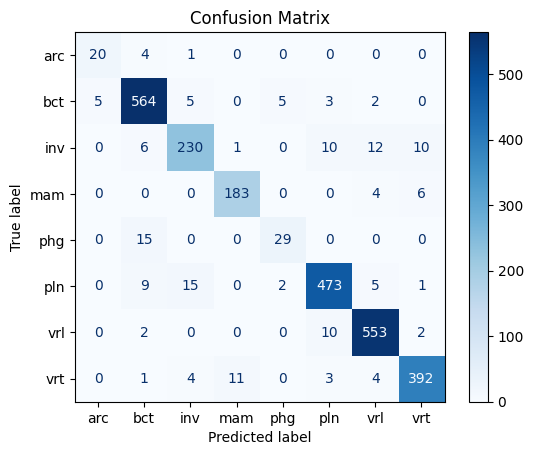

In [59]:
# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')

# Save the CM as an image
plt.title("Confusion Matrix")
plt.savefig('Ensemble_confusion matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
report = classification_report(y_test, final_predictions)

# Print title
print(" "* 15 + "   Ensemble CLASSIFICATION REPORT\n")

# Print report
print(report)

                  Ensemble CLASSIFICATION REPORT

              precision    recall  f1-score   support

         arc       0.80      0.80      0.80        25
         bct       0.94      0.97      0.95       584
         inv       0.90      0.86      0.88       269
         mam       0.94      0.95      0.94       193
         phg       0.81      0.66      0.72        44
         pln       0.95      0.94      0.94       505
         vrl       0.95      0.98      0.96       567
         vrt       0.95      0.94      0.95       415

    accuracy                           0.94      2602
   macro avg       0.90      0.89      0.89      2602
weighted avg       0.94      0.94      0.94      2602

